In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import stanza

plt.style.use('ggplot')

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re
import nltk

try:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    print("Downloads concluídos com sucesso.")
except Exception as e:
    print(f"Erro no download: {e}")


Downloads concluídos com sucesso.


In [3]:
# Carregar dados de teste
df_test = pd.read_csv("../src/Tweets_EN_sentiment_test.csv")
df_train = pd.read_csv("../src/Tweets_EN_sentiment_train.csv")
# Informação básica sobre o dataset
print("Informação do dataset:")
print(df_test.info())

Informação do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2122 entries, 0 to 2121
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   2122 non-null   int64 
 1   text    2100 non-null   object
 2   class   2122 non-null   object
dtypes: int64(1), object(2)
memory usage: 49.9+ KB
None


In [4]:
stopwords = nltk.corpus.stopwords.words('english')
print("total words:", len(stopwords))
print(stopwords)

palavras_negacao = {'not', 'no', 'nor', 'against', "don't", "aren't", "couldn't",
                    "didn't", "doesn't", "hadn't", "hasn't", "haven't", "isn't",
                    "mightn't", "mustn't", "needn't", "shan't", "shouldn't",
                    "wasn't", "weren't", "won't", "wouldn't"}

stopwords_clean = [word for word in stopwords if word not in palavras_negacao]
print(stopwords_clean)


total words: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan

Remover URLs e menções (@utilizador) através de expressões regulares (Regex), pois não contêm valor de sentimento.

Filtrar caracteres não alfanuméricos, mantendo a pontuação expressiva como exclamações e emojis.

Preservar a capitalização (palavras em MAIÚSCULAS), dado que intensificam a polaridade nas métricas.

Filtrar stop words, garantindo que negações cruciais como "not" ou "no" são mantidas para não destruir o contexto.

Aplicar lematização para reduzir as palavras à sua forma base, facilitando o cruzamento com o dicionário do léxico.

STANZA - ele considera alguns stopwords relevantes como "but" etc. Não retirar.
VADER - consegue ler emojis #utilizando a biblioteca emoji para transformar "I love this 😭" em "I love this :loudly_crying_face:"
TextBlob - não diferencia maiúsculas de minúsculas no seu cálculo de polaridade, mas o VADER usa isso como um multiplicador.

In [5]:
'''def pre_processamento(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    # 2. Manter letras, números, espaços e pontuação vital (! ? ')
    text = re.sub(r'[^\w\s\?\!\']', '', text)

    tokens = word_tokenize(text)

    tokens_limpos = []
    for w in tokens:
        if w.lower() not in stopwords_clean:
            lema = lemmatizer.lemmatize(w.lower())
            if w.isupper() and len(w) > 1:
                tokens_limpos.append(lema.upper())
            else:
                tokens_limpos.append(lema)
    return ' '.join(tokens_limpos)

# Aplicação segura aos dados
df_test['text_clean'] = df_test['text'].apply(pre_processamento)'''

<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
C:\Users\ferna\AppData\Local\Temp\ipykernel_18368\161794367.py:5: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub(r'http\S+|www\S+|https\S+', '', text)


'def pre_processamento(text):\n    if not isinstance(text, str):\n        return ""\n\n    text = re.sub(r\'http\\S+|www\\S+|https\\S+\', \'\', text)\n    text = re.sub(r\'@\\w+\', \'\', text)\n    text = re.sub(r\'#\', \'\', text)\n\n    # 2. Manter letras, números, espaços e pontuação vital (! ? \')\n    text = re.sub(r\'[^\\w\\s\\?\\!\']\', \'\', text)\n\n    tokens = word_tokenize(text)\n\n    tokens_limpos = []\n    for w in tokens:\n        if w.lower() not in stopwords_clean:\n            lema = lemmatizer.lemmatize(w.lower())\n            if w.isupper() and len(w) > 1:\n                tokens_limpos.append(lema.upper())\n            else:\n                tokens_limpos.append(lema)\n    return \' \'.join(tokens_limpos)\n\n# Aplicação segura aos dados\ndf_test[\'text_clean\'] = df_test[\'text\'].apply(pre_processamento)'

Vamos criar uma versão do dataset sem números e comparar os resultados (Accuracy/F1-Score) com a versão que mantém os números.

Se decidirmos avançar com a remoção de números, basta alterar uma única linha na função de limpeza:

text = re.sub(r'[^a-zA-Z\s\?\!\']', '', text)

Se o seu dataset for desequilibrado (por exemplo, se 80% dos tweets totais forem positivos), estabelece-se a regra de que qualquer empate ou falta de sinal (zero) é classificado automaticamente como "pos". É uma heurística de negócio utilizada para maximizar a probabilidade estatística de acerto quando o algoritmo falha.

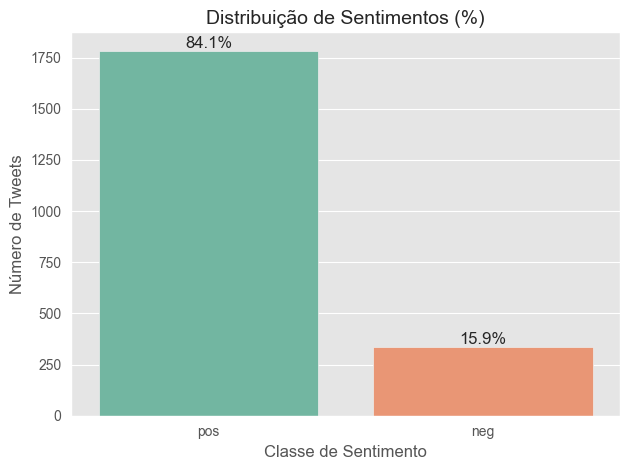

In [6]:
ax = sns.countplot(data=df_test, x='class', hue='class', palette='Set2', legend=False)

total = len(df_test['class'])

for p in ax.patches:
    percentagem = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentagem, (x, y), ha='center', va='bottom', fontsize=12)

plt.title('Distribuição de Sentimentos (%)', fontsize=14)
plt.xlabel('Classe de Sentimento', fontsize=12)
plt.ylabel('Número de Tweets', fontsize=12)
plt.tight_layout()
plt.show()

É deveras desequilibrado :)

Por isso vamos aplicar as seguintes regras -
VADER e TextBlob, Qualquer score contínuo de $0.0$ (neutro) é automaticamente classificado como "pos"
Stanza, Qualquer média de $1.0$ (neutro na escala Stanford) ou falha na leitura (texto vazio) é automaticamente absorvida pela classe "pos"

Cenários de limpeza distintos

Cenário A (Baseline), Limpeza segura que mantém pontuação expressiva, números, capitalização e remove apenas as stopwords irrelevantes.

Cenário B (Sem Números), Retira puramente os dígitos para testar o nível de ruído provocado por gírias e classificações numéricas.

Cenário C (Full Context), Não remove nenhuma stopword, preservando a sintaxe absoluta da frase para testar se os modelos neurais (Stanza) beneficiam da gramática completa.

In [7]:
lemmatizer = WordNetLemmatizer()


def limpar_texto_base(text):
    if not isinstance(text, str):
        return ""

    # remover links e placeholders
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'\bUSER\b', '', text)
    text = re.sub(r'\bURL\b', '', text)

    # remover menções reais
    text = re.sub(r'@\w+', '', text)

    # remover RT no início
    text = re.sub(r'^\s*RT\s+', '', text)

    # remover símbolo # mas manter a palavra
    text = re.sub(r'#', '', text)

    # manter letras, números, espaços e pontuação relevante
    text = re.sub(r'[^\w\s\?\!\']', '', text)

    # remover espaços extra
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def processar_tokens(text, remove_stopwords=True, remove_numbers=False, full_context=False, use_lemmatization=True):
    if not isinstance(text, str):
        return ""

    text = limpar_texto_base(text)
    if not text:
        return ""

    tokens = word_tokenize(text)
    tokens_limpos = []

    for w in tokens:
        # manter pontuação relevante
        if w in {'!', '?'}:
            tokens_limpos.append(w)
            continue

        # remover números apenas quando pedido
        if remove_numbers and re.fullmatch(r'\d+([.,:/-]\d+)*', w):
            continue

        # remover tokens sem conteúdo útil
        if not re.search(r"[A-Za-z0-9#']", w):
            continue

        base = w

        if not base:
            continue

        # cenário full context mantém stopwords
        if not full_context and remove_stopwords and base.lower() in stopwords_clean:
            continue

        # lematização opcional
        if use_lemmatization:
            token_final = lemmatizer.lemmatize(base.lower())
        else:
            token_final = base.lower()

        # preservar ALL CAPS
        if base.isupper() and len(base) > 1:
            token_final = token_final.upper()

        tokens_limpos.append(token_final)

    return ' '.join(tokens_limpos)


# Cenário A
def prep_baseline(text):
    if not isinstance(text, str):
        return ""
    return processar_tokens(
        text,
        remove_stopwords=True,
        remove_numbers=False,
        full_context=False,
        use_lemmatization=True
    )

# Cenário B
def prep_full_context(text):
    if not isinstance(text, str):
        return ""
    return processar_tokens(
        text,
        remove_stopwords=False,
        remove_numbers=False,
        full_context=True,
        use_lemmatization=True
    )


# Cenário C - sem lematização
def prep_sem_lematizacao(text):
    if not isinstance(text, str):
        return ""
    return processar_tokens(
        text,
        remove_stopwords=True,
        remove_numbers=False,
        full_context=False,
        use_lemmatization=False
    )


# Mapeamento ao dataset
df_test['text_baseline'] = df_test['text'].apply(prep_baseline)
df_test['text_full_context'] = df_test['text'].apply(prep_full_context)
df_test['text_sem_lematizacao'] = df_test['text'].apply(prep_sem_lematizacao)

print("Cenários processados com sucesso.")

Cenários processados com sucesso.


In [8]:
# Ver alguns exemplos do pré-processamento
df_test[['text', 'text_baseline', 'text_full_context', 'text_sem_lematizacao']].head(10)

,text,text_baseline,text_sem_numeros,text_full_context,text_sem_lematizacao
0,lmao i love it.,lmao love,lmao love,lmao i love it,lmao love
1,"Never been to Australia, but I'll keep that in...",never australia 'll keep mind eat mcdonald 's ...,never australia 'll keep mind eat mcdonald 's ...,never been to australia but i 'll keep that in...,never australia 'll keep mind eat mcdonald 's ...
2,Tired as shit...but what else is new...and don...,tired shitbut else newand n't want go work day...,tired shitbut else newand n't want go work day...,tired a shitbut what else is newand do n't wan...,tired shitbut else newand n't want go work day...
3,Levi's!,levi 's !,levi 's !,levi 's !,levi 's !
4,"no sweetie, its not love, probably just heart ...",no sweetie not love probably heart burn get tw...,no sweetie not love probably heart burn get tw...,no sweetie it not love probably just heart bur...,no sweetie not love probably heart burn get tw...
5,"I am eating chocolate chips, pecans and peanut...",eating chocolate chip pecan peanut butter jar ...,eating chocolate chip pecan peanut butter jar ...,i am eating chocolate chip pecan and peanut bu...,eating chocolate chips pecans peanut butter ja...
6,"Yes, that frank lloyd wright house, a man has ...",yes frank lloyd wright house man goal know,yes frank lloyd wright house man goal know,yes that frank lloyd wright house a man ha to ...,yes frank lloyd wright house man goals know
7,"Yeah, pretty much...",yeah pretty much,yeah pretty much,yeah pretty much,yeah pretty much
8,"ben gaar, ook nog zakelijk diner vanavond. eve...",ben gaar ook nog zakelijk diner vanavond even ...,ben gaar ook nog zakelijk diner vanavond even ...,ben gaar ook nog zakelijk diner vanavond even ...,ben gaar ook nog zakelijk diner vanavond even ...
9,"My photoshop skills lag, but I can assure you ...",photoshop skill lag assure cabo cloudy today h...,photoshop skill lag assure cabo cloudy today h...,my photoshop skill lag but i can assure you ca...,photoshop skills lag assure cabo cloudy today ...


In [9]:
# Inicializar modelos
analyzer_vader = SentimentIntensityAnalyzer()

# Download Stanza model (só precisa fazer uma vez)
# stanza.download('en')
nlp_stanza = stanza.Pipeline('en', processors='tokenize,sentiment', verbose=False)

In [10]:
def classificar_textblob(text):
    """
    TextBlob: score > 0 = pos, caso contrário = pos (regra do dataset desbalanceado)
    """
    if not text or text.strip() == '':
        return 'pos'

    polarity = TextBlob(text).sentiment.polarity
    return 'pos' if polarity >= 0 else 'neg'

In [11]:
def classificar_vader(text):
    """
    VADER: compound >= 0.0 = pos (regra do desbalanceamento)
    Threshold ajustado de 0.05 para 0.0 devido ao desbalanceamento
    """
    if not text or text.strip() == '':
        return 'pos'

    scores = analyzer_vader.polarity_scores(text)
    compound = scores['compound']

    return 'pos' if compound >= 0.0 else 'neg'

In [12]:
def classificar_stanza(text):
    """
    Stanza: 0=neg, 1=neutral, 2=pos
    Neutral (1.0) é classificado como 'pos' (regra do desbalanceamento)
    """
    if not text or text.strip() == '':
        return 'pos'

    try:
        doc = nlp_stanza(text)
        sentimentos = [sentence.sentiment for sentence in doc.sentences]
        media = np.mean(sentimentos) if sentimentos else 1.0
        return 'pos' if media >= 1.0 else 'neg'
    except:
        return 'pos'

In [13]:
## 5. Aplicar Modelos aos 3 Cenários

In [14]:
# Lista de cenários
cenarios = ['text_baseline', 'text_full_context', 'text_sem_lematizacao']
modelos = ['textblob', 'vader', 'stanza']

# Aplicar cada modelo a cada cenário
for cenario in cenarios:
    print(f"Processando cenário: {cenario}")

    # TextBlob
    df_test[f'{cenario}_pred_textblob'] = df_test[cenario].apply(classificar_textblob)

    # VADER
    df_test[f'{cenario}_pred_vader'] = df_test[cenario].apply(classificar_vader)

    # Stanza
    df_test[f'{cenario}_pred_stanza'] = df_test[cenario].apply(classificar_stanza)

print("Classificações concluídas!")

Processando cenário: text_baseline
Processando cenário: text_sem_numeros
Processando cenário: text_full_context
Processando cenário: text_sem_lematizacao
Classificações concluídas!


In [15]:
# Ver alguns exemplos
df_test[['text', 'class',
         'text_baseline_pred_textblob',
         'text_baseline_pred_vader',
         'text_baseline_pred_stanza',
         'text_sem_lematizacao_pred_textblob',
         'text_sem_lematizacao_pred_vader',
         'text_sem_lematizacao_pred_stanza']].head(10)

,text,class,text_baseline_pred_textblob,text_baseline_pred_vader,text_baseline_pred_stanza,text_sem_lematizacao_pred_textblob,text_sem_lematizacao_pred_vader,text_sem_lematizacao_pred_stanza
0,lmao i love it.,pos,pos,pos,pos,pos,pos,pos
1,"Never been to Australia, but I'll keep that in...",pos,pos,pos,pos,pos,pos,pos
2,Tired as shit...but what else is new...and don...,neg,neg,neg,neg,neg,neg,neg
3,Levi's!,pos,pos,pos,pos,pos,pos,pos
4,"no sweetie, its not love, probably just heart ...",pos,pos,neg,neg,pos,neg,neg
5,"I am eating chocolate chips, pecans and peanut...",pos,neg,neg,neg,neg,neg,neg
6,"Yes, that frank lloyd wright house, a man has ...",pos,pos,pos,pos,pos,pos,pos
7,"Yeah, pretty much...",pos,pos,pos,pos,pos,pos,pos
8,"ben gaar, ook nog zakelijk diner vanavond. eve...",pos,pos,pos,pos,pos,pos,pos
9,"My photoshop skills lag, but I can assure you ...",pos,pos,pos,neg,pos,pos,neg


In [16]:
# Função para calcular métricas
def avaliar_modelo(y_true, y_pred, nome_modelo, nome_cenario):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label='pos', zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label='pos', zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label='pos', zero_division=0)

    return {
        'Cenário': nome_cenario,
        'Modelo': nome_modelo,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }

In [17]:
# Calcular métricas para todos os cenários e modelos
resultados = []
y_true = df_test['class']

nomes_cenarios = {
    'text_baseline': 'Baseline',
    'text_sem_numeros': 'Sem Números',
    'text_full_context': 'Full Context',
    'text_sem_lematizacao': 'Sem Lematização'
}

for cenario in cenarios:
    for modelo in modelos:
        col_pred = f'{cenario}_pred_{modelo}'
        y_pred = df_test[col_pred]

        resultado = avaliar_modelo(
            y_true,
            y_pred,
            modelo.upper(),
            nomes_cenarios[cenario]
        )
        resultados.append(resultado)

# Criar DataFrame de resultados
df_resultados = pd.DataFrame(resultados)
df_resultados

,Cenário,Modelo,Accuracy,Precision,Recall,F1-Score
0,Baseline,TEXTBLOB,0.810085,0.876294,0.901345,0.888643
1,Baseline,VADER,0.817154,0.895692,0.885650,0.890643
2,Baseline,STANZA,0.777097,0.901901,0.824552,0.861493
3,Sem Números,TEXTBLOB,0.810085,0.876294,0.901345,0.888643
4,Sem Números,VADER,0.817154,0.895692,0.885650,0.890643
5,Sem Números,STANZA,0.778982,0.900183,0.829036,0.863146
6,Full Context,TEXTBLOB,0.805372,0.877686,0.892937,0.885246
7,Full Context,VADER,0.821395,0.895329,0.891816,0.893569
8,Full Context,STANZA,0.763431,0.909847,0.797646,0.850060
9,Sem Lematização,TEXTBLOB,0.812441,0.878275,0.901906,0.889934


## VISUALIZAÇÕES

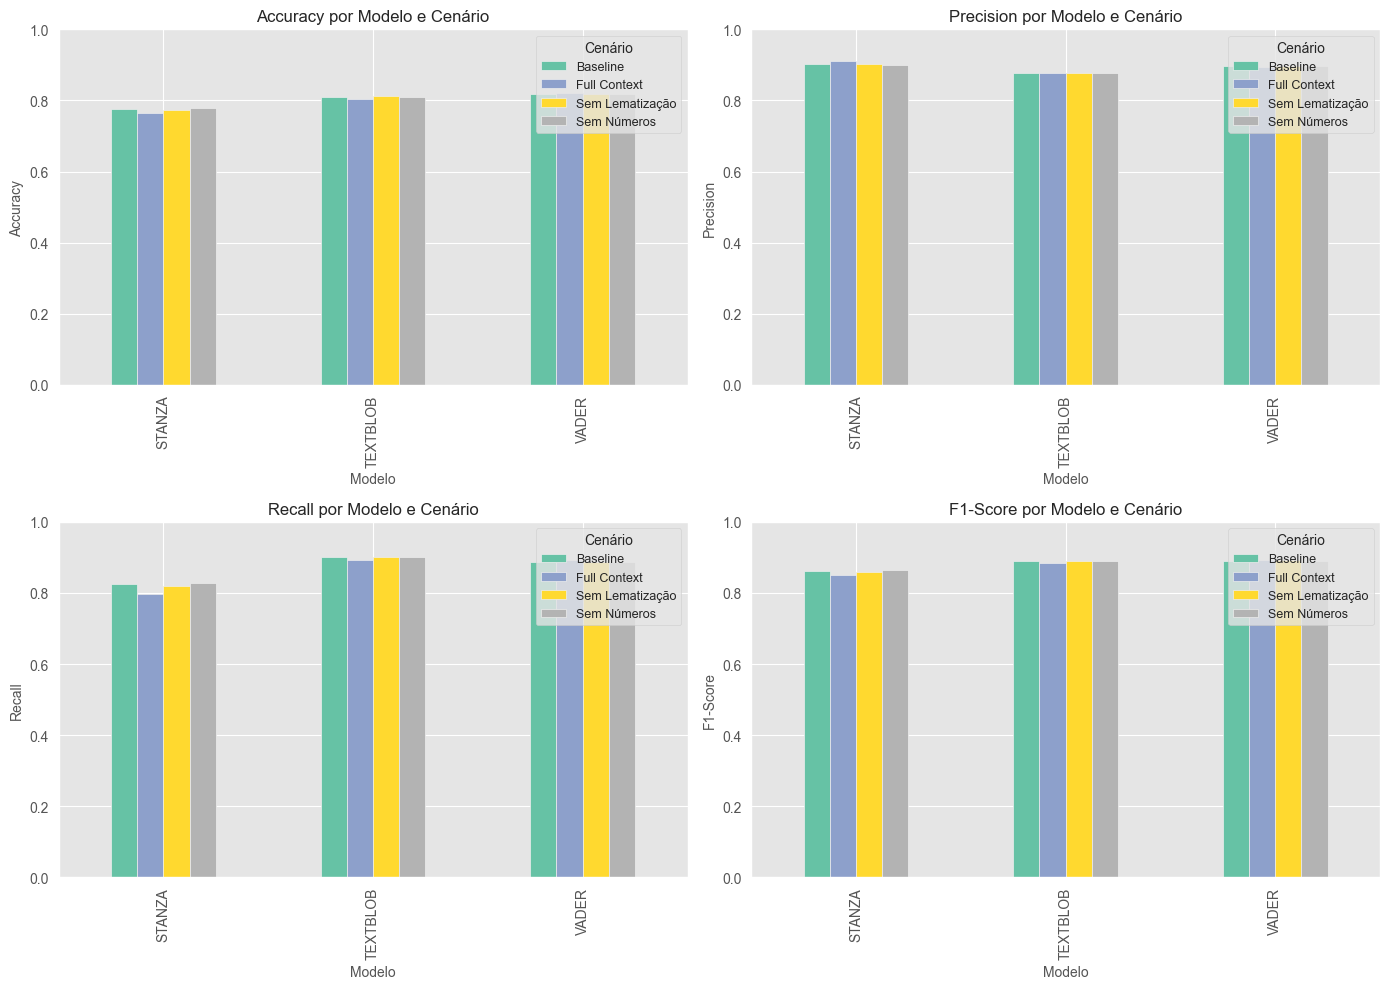

In [18]:
# Comparação por modelo..
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, metrica in enumerate(metricas):
    ax = axes[idx // 2, idx % 2]

    pivot = df_resultados.pivot(index='Modelo', columns='Cenário', values=metrica)
    pivot.plot(kind='bar', ax=ax, colormap='Set2')

    ax.set_title(f'{metrica} por Modelo e Cenário', fontsize=12)
    ax.set_ylabel(metrica, fontsize=10)
    ax.set_xlabel('Modelo', fontsize=10)
    ax.legend(title='Cenário', fontsize=9)
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('comparacao_modelos_lexicos.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# Melhor modelo por cenário
print("Melhores modelos por F1-Score:\n")
for cenario_nome in nomes_cenarios.values():
    melhor = df_resultados[df_resultados['Cenário'] == cenario_nome].nlargest(1, 'F1-Score')
    print(f"{cenario_nome}: {melhor['Modelo'].values[0]} - F1={melhor['F1-Score'].values[0]:.4f}")


Melhores modelos por F1-Score:

Baseline: VADER - F1=0.8906
Sem Números: VADER - F1=0.8906
Full Context: VADER - F1=0.8936
Sem Lematização: VADER - F1=0.8917


## MATRIZES DE CONFUSÃO

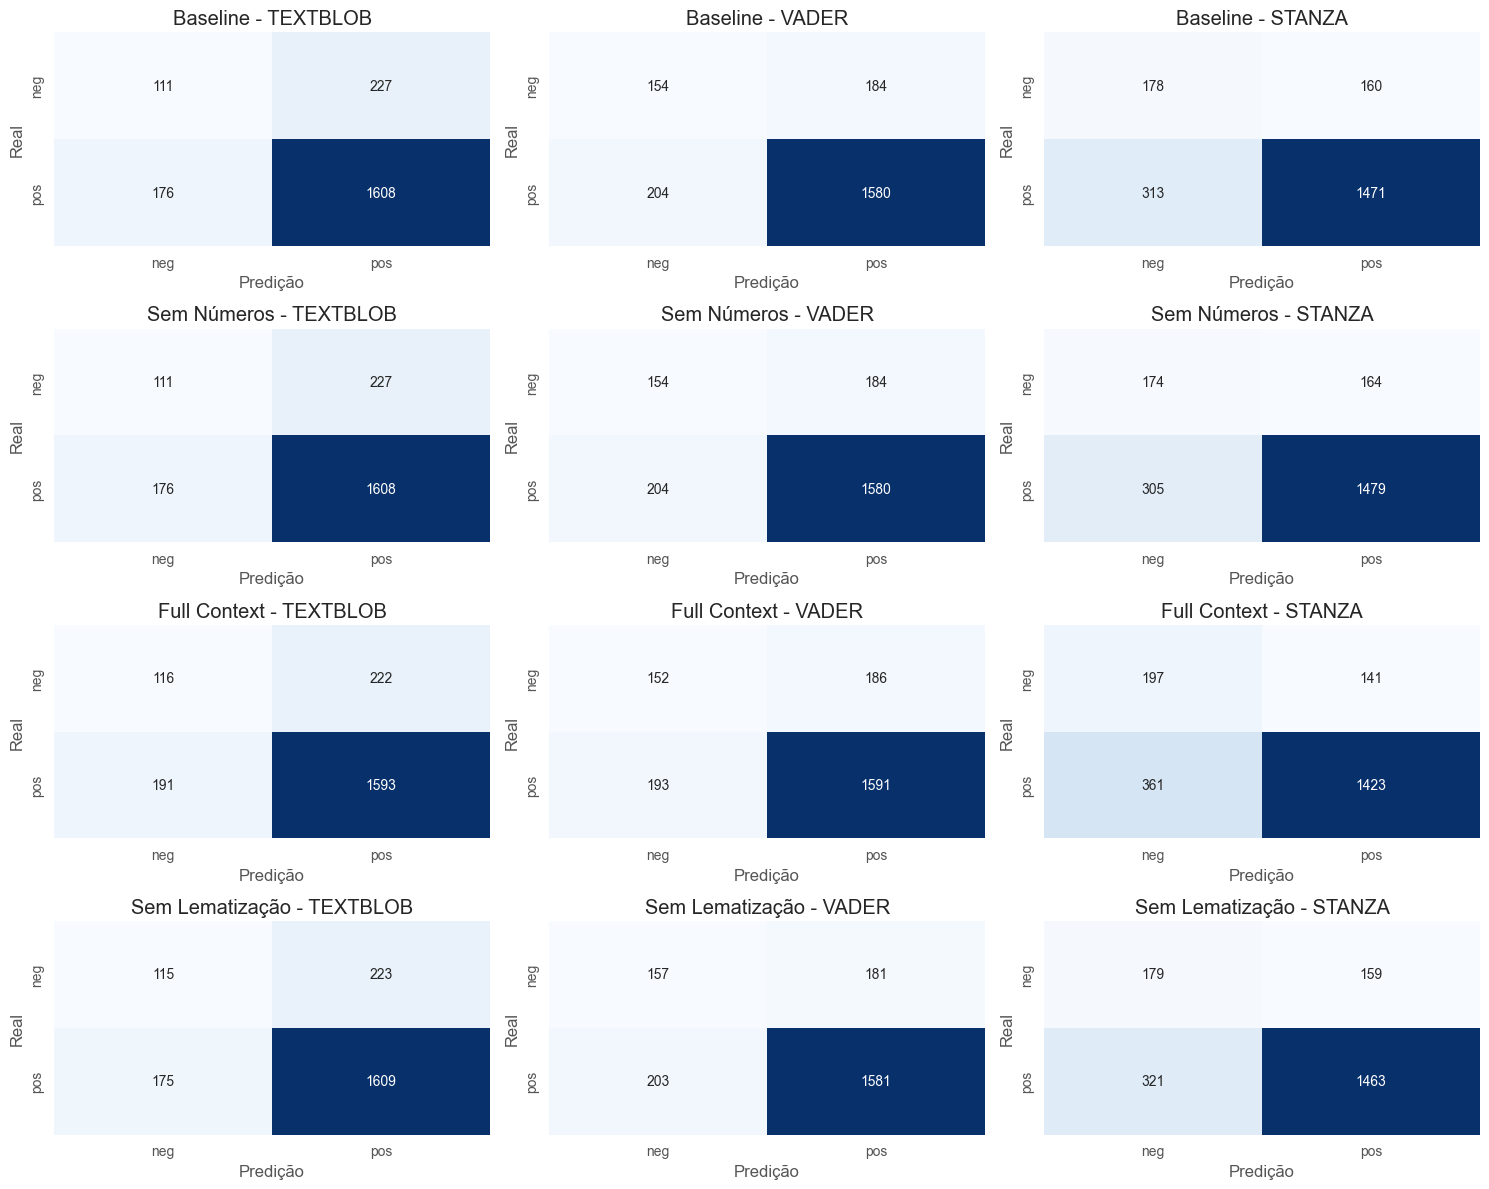

In [20]:
fig, axes = plt.subplots(len(cenarios), len(modelos), figsize=(15, 12))

for i, cenario in enumerate(cenarios):
    for j, modelo in enumerate(modelos):
        col_pred = f'{cenario}_pred_{modelo}'
        cm = confusion_matrix(df_test['class'], df_test[col_pred], labels=['neg', 'pos'])

        ax = axes[i, j]

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=False,
            xticklabels=['neg', 'pos'],
            yticklabels=['neg', 'pos'],
            ax=ax
        )

        ax.set_title(f"{nomes_cenarios[cenario]} - {modelo.upper()}")
        ax.set_xlabel("Predição")
        ax.set_ylabel("Real")

plt.tight_layout()
plt.savefig('matrizes_confusao_grid.png', dpi=300)
plt.show()

In [24]:
# Guardar resultados
df_resultados.to_csv('resultados_modelos_lexicos.csv', index=False)
df_test.to_csv('df_test_com_predicoes.csv', index=False)


In [23]:
# Releitura rápida dos resultados

df_resultados = pd.read_csv('resultados_modelos_lexicos.csv')
df_test = pd.read_csv('df_test_com_predicoes.csv')

## Tranformers

In [25]:
from transformers import pipeline
import torch

In [34]:
def limpar_para_transformers(text):
    if not isinstance(text, str) or text.strip() == '':
        return ""

    # Remover apenas URLs e placeholders USER
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'\bUSER\b', '', text)
    text = re.sub(r'\bURL\b', '', text)
    text = re.sub(r'^\s*RT\s+', '', text)

    # Limpar espaços extra
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [35]:
df_test['text_transformers'] = df_test['text'].apply(limpar_para_transformers)
df_train['text_transformers'] = df_train['text'].apply(limpar_para_transformers)

In [36]:
df_test[['text', 'text_transformers']].head(5)

,text,text_transformers
0,lmao i love it.,lmao i love it.
1,"Never been to Australia, but I'll keep that in...","Never been to Australia, but I'll keep that in..."
2,Tired as shit...but what else is new...and don...,Tired as shit...but what else is new...and don...
3,Levi's!,Levi's!
4,"no sweetie, its not love, probably just heart ...","no sweetie, its not love, probably just heart ..."


In [37]:
# Inicializar pipeline DistilBERT
print("Carregando modelo DistilBERT...")
distilbert_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=512
)

Carregando modelo DistilBERT...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3437.60it/s]


In [38]:
def classificar_distilbert(textos, batch_size=32):
    """
    Classifica textos usando DistilBERT.
    Processa em batch para eficiência.
    """
    if isinstance(textos, str):
        textos = [textos]

    # Garantir que não há textos vazios
    textos_limpos = []
    for t in textos:
        if isinstance(t, str) and t.strip():
            textos_limpos.append(t)
        else:
            textos_limpos.append("neutral text")  # placeholder para vazios

    # Processar em batches
    resultados = []
    for i in range(0, len(textos_limpos), batch_size):
        batch = textos_limpos[i:i + batch_size]
        preds = distilbert_pipeline(batch)
        resultados.extend(preds)

    # Converter POSITIVE/NEGATIVE para pos/neg
    return ['pos' if r['label'] == 'POSITIVE' else 'neg' for r in resultados]


In [40]:
# Aplicar DistilBERT aos dados de teste
df_test['pred_distilbert'] = classificar_distilbert(df_test['text_transformers'].tolist())

In [41]:
# Avaliar resultados
resultado_distilbert = avaliar_modelo(
    df_test['class'],
    df_test['pred_distilbert'],
    'DISTILBERT',
    'Transformers'
)

# Adicionar aos resultados existentes
df_resultados = pd.concat([
    df_resultados,
    pd.DataFrame([resultado_distilbert])
], ignore_index=True)

print("\n📊 Resultados DistilBERT:")
print(df_resultados[df_resultados['Modelo'] == 'DISTILBERT'])


📊 Resultados DistilBERT:
         Cenário      Modelo  Accuracy  Precision    Recall  F1-Score
12  Full Context  DISTILBERT  0.605090   0.944549  0.563341  0.705758
13  Transformers  DISTILBERT  0.637606   0.945566  0.603700  0.736914


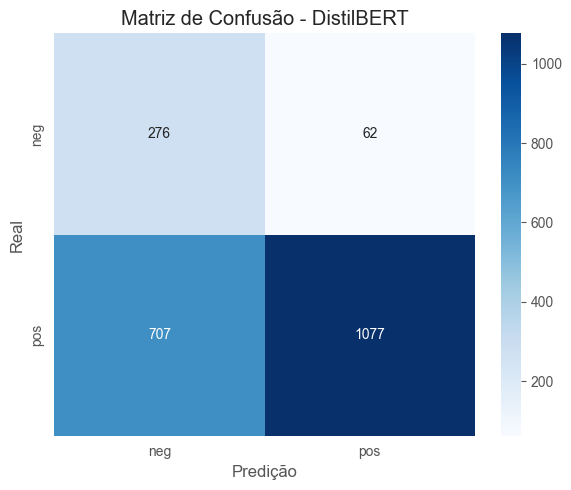


🎯 F1-Score DistilBERT: 0.7369
📊 Accuracy: 0.6376


In [42]:
# Matriz de confusão para DistilBERT
cm_distilbert = confusion_matrix(
    df_test['class'],
    df_test['pred_distilbert'],
    labels=['neg', 'pos']
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_distilbert,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['neg', 'pos'],
    yticklabels=['neg', 'pos'],
    cbar=True
)
plt.title('Matriz de Confusão - DistilBERT')
plt.xlabel('Predição')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('confusion_matrix_distilbert.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nF1-Score DistilBERT: {resultado_distilbert['F1-Score']:.4f}")
print(f"Accuracy: {resultado_distilbert['Accuracy']:.4f}")

In [43]:
# Verificar textos vazios/problemáticos
print("Textos vazios no teste:")
print(df_test['text'].isna().sum())
print(df_test['text_transformers'].isna().sum())

print("\nTextos que ficaram vazios após limpeza:")
vazios = df_test[df_test['text_transformers'].str.strip() == '']
print(f"Total: {len(vazios)}")
print(vazios[['text', 'text_transformers', 'class']].head(10))

print("\nDistribuição das predições:")
print(df_test['pred_distilbert'].value_counts())

print("\nDistribuição real:")
print(df_test['class'].value_counts())

Textos vazios no teste:
22
0

Textos que ficaram vazios após limpeza:
Total: 26
     text text_transformers class
14    NaN                     pos
57    NaN                     neg
93    NaN                     pos
193  URL                      pos
242   NaN                     neg
448   NaN                     neg
481   NaN                     neg
682   NaN                     pos
695   NaN                     neg
864  URL                      pos

Distribuição das predições:
pred_distilbert
pos    1139
neg     983
Name: count, dtype: int64

Distribuição real:
class
pos    1784
neg     338
Name: count, dtype: int64


In [46]:
# Reclassificar com probabilidades e threshold ajustado
print("Reclassificando com threshold ajustado...")


def classificar_distilbert_ajustado(textos, threshold=0.3, batch_size=32):
    """
    Threshold mais baixo = mais permissivo com 'pos' (bom para datasets desbalanceados)
    threshold=0.3 significa: só classifica 'neg' se prob(neg) > 0.7
    """
    if isinstance(textos, str):
        textos = [textos]

    textos_limpos = []
    for t in textos:
        if isinstance(t, str) and t.strip():
            textos_limpos.append(t)
        else:
            textos_limpos.append("neutral text")

    resultados = []
    for i in range(0, len(textos_limpos), batch_size):
        batch = textos_limpos[i:i + batch_size]
        preds = distilbert_pipeline(batch)
        resultados.extend(preds)

    # Usar score para threshold customizado
    labels = []
    for r in resultados:
        if r['label'] == 'NEGATIVE':
            # Só aceita NEG se tiver alta confiança
            labels.append('neg' if r['score'] > (1 - threshold) else 'pos')
        else:
            # Aceita POS com confiança mais baixa
            labels.append('pos' if r['score'] > threshold else 'neg')

    return labels

Reclassificando com threshold ajustado...


In [47]:

# Testar diferentes thresholds
thresholds = [0.3, 0.4, 0.5]

for thresh in thresholds:
    df_test[f'pred_distilbert_t{int(thresh * 10)}'] = classificar_distilbert_ajustado(
        df_test['text_transformers'].tolist(),
        threshold=thresh
    )

    resultado = avaliar_modelo(
        df_test['class'],
        df_test[f'pred_distilbert_t{int(thresh * 10)}'],
        f'DISTILBERT (threshold={thresh})',
        'Transformers'
    )

    print(f"\nThreshold {thresh}:")
    print(f"F1-Score: {resultado['F1-Score']:.4f}")
    print(f"Accuracy: {resultado['Accuracy']:.4f}")
    print(f"Distribuição: {df_test[f'pred_distilbert_t{int(thresh * 10)}'].value_counts().to_dict()}")


Threshold 0.3:
F1-Score: 0.7480
Accuracy: 0.6484
Distribuição: {'pos': 1176, 'neg': 946}

Threshold 0.4:
F1-Score: 0.7462
Accuracy: 0.6470
Distribuição: {'pos': 1167, 'neg': 955}

Threshold 0.5:
F1-Score: 0.7369
Accuracy: 0.6376
Distribuição: {'pos': 1139, 'neg': 983}
